# Imports

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
from typing import List
from torch.optim import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from torch.utils.data import Dataset, random_split, DataLoader

# LReLU Implementation in Python

In [2]:
def leaky_relu(x, alpha=0.01):
    return max(alpha * x, x)

# Globals

In [3]:
device = 'cuda'

# Dataset

In [4]:
class BostonDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        self.df = pd.read_csv(csv_path).dropna()
        X_df: pd.DataFrame = self.df[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']]
        X_np = X_df.to_numpy(np.float32)
        self.X = torch.from_numpy(X_np)
        
        Y_df = self.df[['MEDV']]
        Y_np = Y_df.to_numpy(np.float32)
        self.Y = torch.from_numpy(Y_np)
        
        print(self.X.shape, self.Y.shape)
        
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
    def __len__(self):
        return len(self.X)

In [5]:
dataset = BostonDataset('dataset/HousingData.csv')

torch.Size([394, 13]) torch.Size([394, 1])


# Model

In [6]:
class BostonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 26),
            nn.ReLU(),
            nn.Linear(26, 26),
            nn.ReLU(),
            nn.Linear(26, 1)
        )
        
    def forward(self, x):
        return self.model(x)

In [7]:
class LeakyBostonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 26),
            nn.LeakyReLU(),
            nn.Linear(26, 26),
            nn.LeakyReLU(),
            nn.Linear(26, 1)
        )
        
    def forward(self, x):
        return self.model(x)

# Metrics Calculation

In [8]:
def graph_loss(loss_ot: List[float]):
    plt.plot(range(1, len(loss_ot) + 1), loss_ot, c='blue', label='Loss Over Time')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
def calc_metrics(Y_true: torch.Tensor, Y_pred: torch.Tensor):
    Y_pred_np = Y_pred.detach().cpu().numpy()
    Y_true_np = Y_true.detach().cpu().numpy()
    
    r2 = r2_score(Y_true_np, Y_pred_np)
    
    return r2

# Inference Loop

In [10]:
def run(model_class, seed, test_size, epochs = 100, lr = 1e-3, print_epochs = False):
    torch.manual_seed(seed=seed)
    np.random.seed(seed=seed)

    train_dataset, test_dataset = random_split(dataset, [1 - test_size, test_size], generator=torch.Generator().manual_seed(seed))
    train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)
    test_loader = DataLoader(test_dataset)
    
    model = model_class().to(device)
    optimiser = Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_loss_ot = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", disable=not print_epochs)
        
        for inputs, targets in pbar:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimiser.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            loss.backward()
            optimiser.step()

            total_loss += loss.item()
            
        avg_train_loss = total_loss / len(train_loader)
        train_loss_ot.append(avg_train_loss)
        if print_epochs:
            print(f'Avg Training Loss = {avg_train_loss}')
    
    model.eval()
    return train_loader, test_loader, model, train_loss_ot

In [11]:
def test(model, test_loader):
    preds = []
    targets = []

    with torch.no_grad():
        for X, Y in test_loader:
            X = X.to(device)
            preds.append(model(X).detach().cpu())
            targets.append(Y)

    Y_pred = torch.cat(preds)
    Y_true = torch.cat(targets)
    r2 = calc_metrics(Y_true, Y_pred)
    print(f'r2 score on test dataset = {r2}')

# Testing

## Seed 321, Test Size 0.3

### ReLU

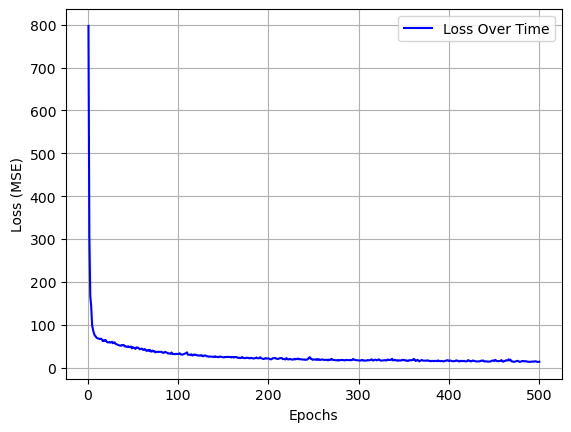

r2 score on test dataset = 0.7812424898147583


In [12]:
train_loader, test_loader, model, loss_ot = run(BostonModel, 321, 0.3, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

### LReLU

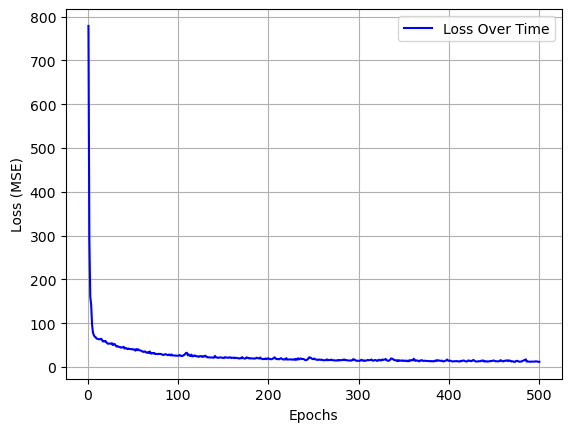

r2 score on test dataset = 0.7857753038406372


In [13]:
train_loader, test_loader, model, loss_ot = run(LeakyBostonModel, 321, 0.3, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

## Seed 42, Test Size 0.2

### ReLU

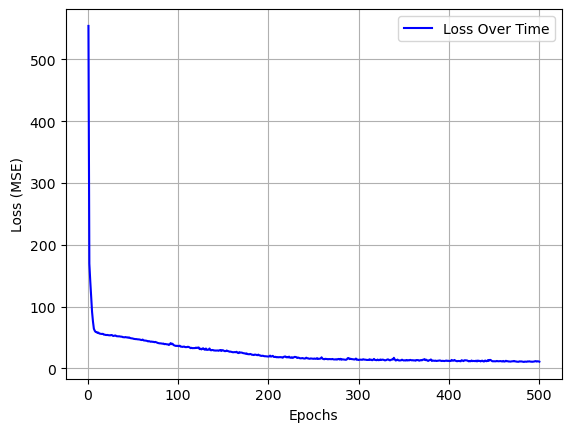

r2 score on test dataset = 0.7028621435165405


In [14]:
train_loader, test_loader, model, loss_ot = run(BostonModel, 42, 0.2, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

### LReLU

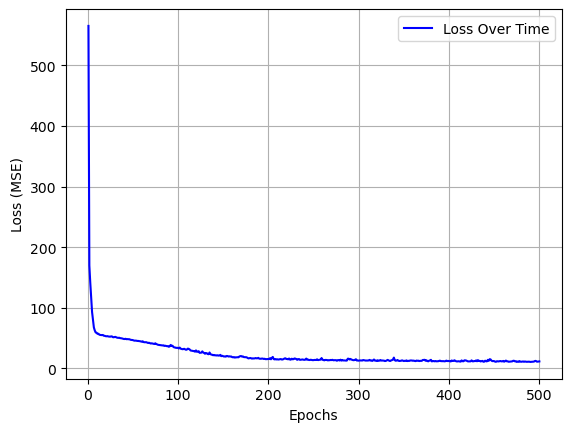

r2 score on test dataset = 0.6761631965637207


In [15]:
train_loader, test_loader, model, loss_ot = run(LeakyBostonModel, 42, 0.2, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

## Seed 21, Test Size 0.1

### ReLU

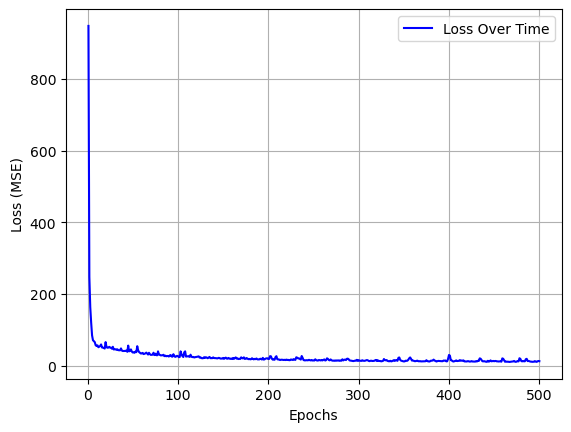

r2 score on test dataset = 0.8281641602516174


In [16]:
train_loader, test_loader, model, loss_ot = run(BostonModel, 21, 0.1, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

### LReLU

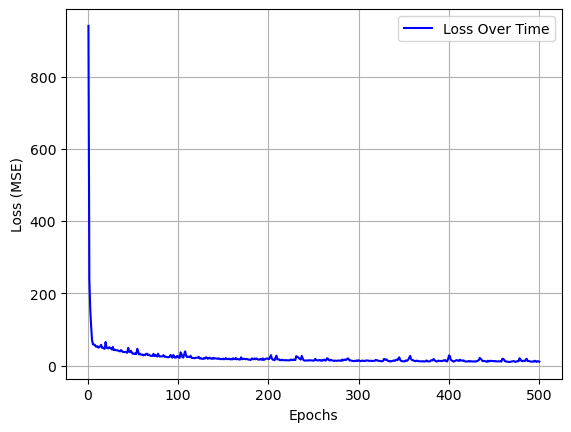

r2 score on test dataset = 0.8362557888031006


In [17]:
train_loader, test_loader, model, loss_ot = run(LeakyBostonModel, 21, 0.1, epochs=500, lr=1e-3)
graph_loss(loss_ot)
test(model, test_loader)

# Results

| Seed  | Test Size | ReLU Used | R2 Score  |
|-------|-----------|-----------|-----------|
|321    | 0.3       | Normal    | 0.781     |
|321    | 0.3       | Leaky     | 0.785     |
|42     | 0.2       | Normal    | 0.702     |
|42     | 0.2       | Leaky     | 0.676     |
|21     | 0.1       | Normal    | 0.828     |
|21     | 0.1       | Leaky     | 0.836     |